In [12]:
import sys
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt

from src.NN_model import initialize_parameters, forward_propagation, cross_entropy_loss
from src.NN_train import train, compute_accuracy

data = np.load('../data/character_dataset.npz', allow_pickle=True)
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']
class_names = data['class_names']

print(X_train.shape, X_val.shape, X_test.shape)

(9800, 784) (2100, 784) (2100, 784)


In [13]:
loaded = np.load('../data/trained_params.npz')
params = {k: loaded[k] for k in loaded.files}

A2_test, _ = forward_propagation(X_test.T, params)
test_acc = compute_accuracy(A2_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.8490


In [14]:
def compute_confusion_matrix(y_true, y_pred, n_classes=35):
    """
    Builds a confusion matrix counting, for every (true class,
    predicted class) pair, how many test samples fell into that
    combination.

    Parameters
    ----------
    y_true : np.ndarray, shape (n_samples,)
        Ground-truth integer class labels.
    y_pred : np.ndarray, shape (n_samples,)
        Predicted integer class labels.
    n_classes : int
        Total number of classes.

    Returns
    -------
    np.ndarray, shape (n_classes, n_classes)
        cm[i, j] = number of samples whose true class was i and
        whose predicted class was j. The diagonal (i == j) holds
        correct predictions; everything else is a specific mistake.
    """
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


cm = compute_confusion_matrix(y_test, y_pred)
print(cm.shape)
print("Total predictions:", cm.sum())
print("Correct (diagonal):", np.trace(cm))
print("Accuracy check:", np.trace(cm) / cm.sum())

(35, 35)
Total predictions: 2100
Correct (diagonal): 1783
Accuracy check: 0.849047619047619


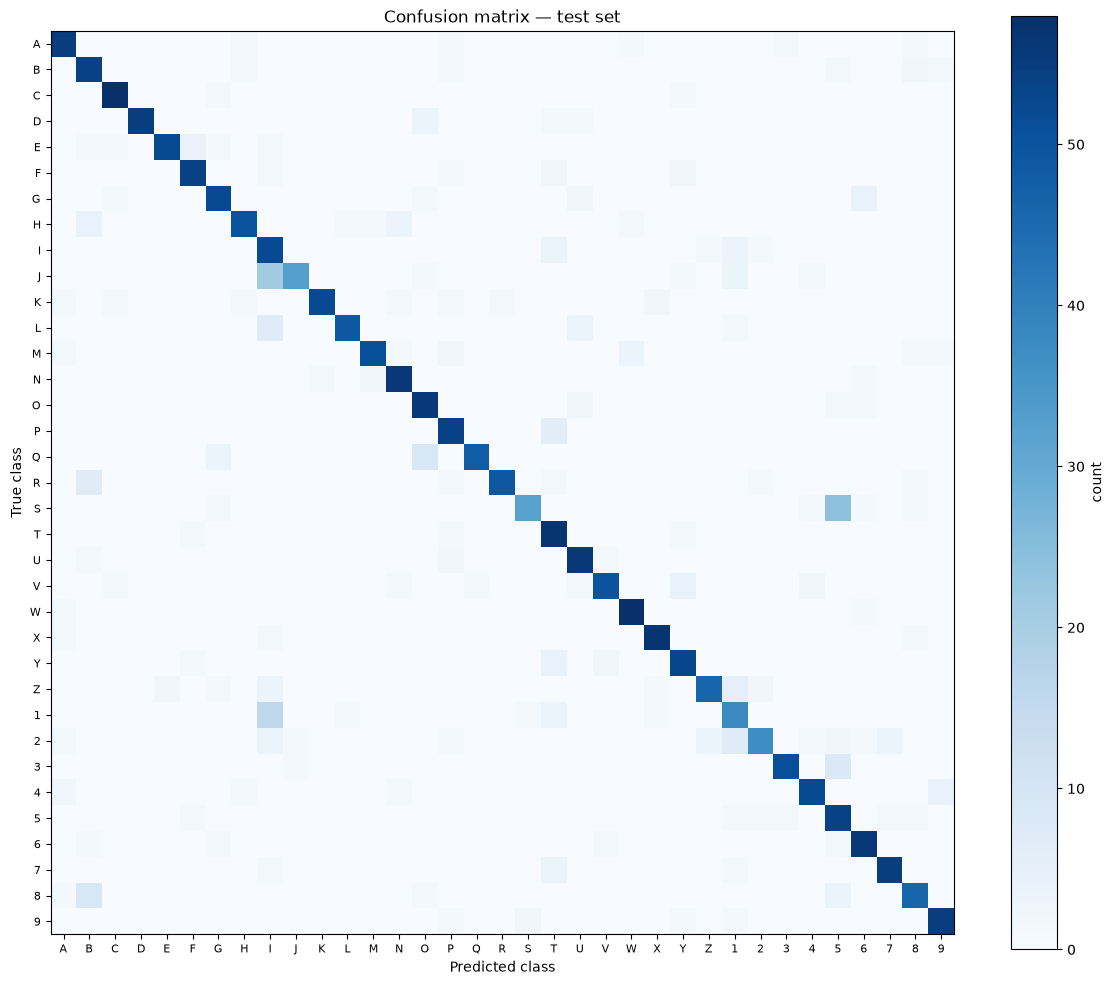

In [15]:
plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap='Blues')
plt.colorbar(label='count')
plt.xticks(range(35), class_names, fontsize=8)
plt.yticks(range(35), class_names, fontsize=8)
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('Confusion matrix — test set')
plt.tight_layout()
plt.show()

Total wrong predictions: 317 out of 2100


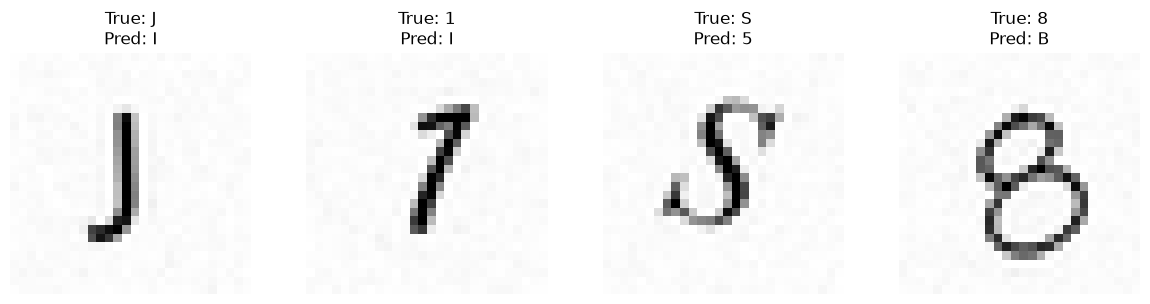

In [16]:
# Find indices where the prediction was wrong
wrong_idx = np.where(y_pred != y_test)[0]
print(f"Total wrong predictions: {len(wrong_idx)} out of {len(y_test)}")

# Pick out a few from the confusions we spotted in the heatmap
def show_examples(true_class_name, pred_class_name, n=1):
    true_c = list(class_names).index(true_class_name)
    pred_c = list(class_names).index(pred_class_name)
    matches = [i for i in wrong_idx if y_test[i] == true_c and y_pred[i] == pred_c]
    return matches[:n]

pairs_to_check = [('I', 'J'), ('J', 'I'), ('1', 'I'), ('S', '5'), ('8', 'B')]
examples = []
for true_c, pred_c in pairs_to_check:
    idxs = show_examples(true_c, pred_c, n=1)
    if idxs:
        examples.append((idxs[0], true_c, pred_c))

fig, axes = plt.subplots(1, len(examples), figsize=(3*len(examples), 3))
for ax, (idx, true_c, pred_c) in zip(axes, examples):
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"True: {true_c}\nPred: {pred_c}")
    ax.axis('off')
plt.tight_layout()
plt.show()

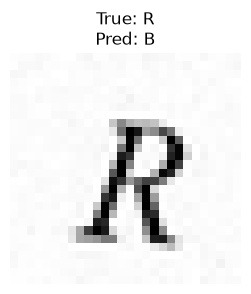

In [17]:
idxs = show_examples('R', 'B', n=1)
if not idxs:
    used = {idx for idx, _, _ in examples}
    idxs = [i for i in wrong_idx if i not in used][:1]

if idxs:
    fig, ax = plt.subplots(figsize=(3, 3))
    idx = idxs[0]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}")
    ax.axis('off')
    plt.show()

In [18]:
np.savez('../data/trained_params.npz',
         W1=params['W1'], b1=params['b1'],
         W2=params['W2'], b2=params['b2'])
print("Saved trained parameters to ../data/trained_params.npz")

Saved trained parameters to ../data/trained_params.npz


In [19]:
loaded = np.load('../data/trained_params.npz')
params_reloaded = {k: loaded[k] for k in loaded.files}

A2_check, _ = forward_propagation(X_test.T, params_reloaded)
acc_check = compute_accuracy(A2_check, y_test)
print(f"Reloaded model test accuracy: {acc_check:.4f}")

Reloaded model test accuracy: 0.8490
